In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("ggplot")
%matplotlib inline

df=pd.read_csv(r"C:\Users\ria\OneDrive\Desktop\Engineering-Campus-Placement-Prediction\data\placement.csv")
df.head()

,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed


In [3]:
df.shape

(401, 16)

In [4]:
df.dtypes

Email                          str
Name                           str
Gender                         str
10th board                     str
10th marks                 float64
12th board                     str
12th marks                 float64
Stream                         str
Cgpa                       float64
Internships(Y/N)               str
Training(Y/N)                  str
Backlog in 5th sem             str
Innovative Project(Y/N)        str
Communication level          int64
Technical Course(Y/N)          str
Placement(Y/N)?                str
dtype: object

In [5]:
df.isnull().sum()

Email                      0
Name                       0
Gender                     0
10th board                 0
10th marks                 0
12th board                 0
12th marks                 0
Stream                     0
Cgpa                       0
Internships(Y/N)           0
Training(Y/N)              0
Backlog in 5th sem         0
Innovative Project(Y/N)    0
Communication level        0
Technical Course(Y/N)      0
Placement(Y/N)?            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop(columns=["Email", "Name"])

In [13]:
for col in df.columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-"*50)

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
10th board:
<StringArray>
['State Board', 'WBBSE', 'CBSE', 'ICSE']
Length: 4, dtype: str
--------------------------------------------------
10th marks:
[ 96.7  96.2  97.5  96.9  99.1  85.5  98.2  79.4  88.   84.3  84.1  97.8
  83.   78.5  95.9  75.   89.8  93.6  87.4  96.3  82.4  87.6  76.9  72.8
  89.3  90.2  77.9  98.5  72.2  93.4  85.6  94.6  79.6  73.8  77.8  77.6
  71.   94.1  72.1  82.6  71.9  80.5  87.2  70.3  75.2  78.9  86.3  75.9
  99.6  95.   72.   88.6  80.7  92.   84.4  86.6  96.4  76.1  75.6  99.9
  91.1  86.4  70.4  86.7  88.1  94.3  85.   82.8  64.   94.   71.8  76.
  96.5  86.9  74.9  73.9  82.1  70.1  82.7  81.9  88.7  93.5  98.9  77.4
  82.3  88.2  96.8  72.6  94.7  81.4  77.7  80.2  89.6  71.4  87.   84.7
  74.8  70.   72.4  93.   60.   85.3  89.2  94.9  98.7  84.6  80.4  80.3
  95.4  87.5  91.8 100.   70.5  86.8  91.4  78.6  90.5  91.9  74.1  81.2
  99.

In [14]:
df["Placement(Y/N)?"].value_counts()

Placement(Y/N)?
Not Placed    202
Placed        199
Name: count, dtype: int64

OBSERVATION:- The target variable (Placement(Y/N)?) is well balanced, with 202 students labeled as "Not Placed" and 199 labeled as "Placed". Since both classes have nearly equal representation, no class balancing techniques such as SMOTE or undersampling are required before training the machine learning models.


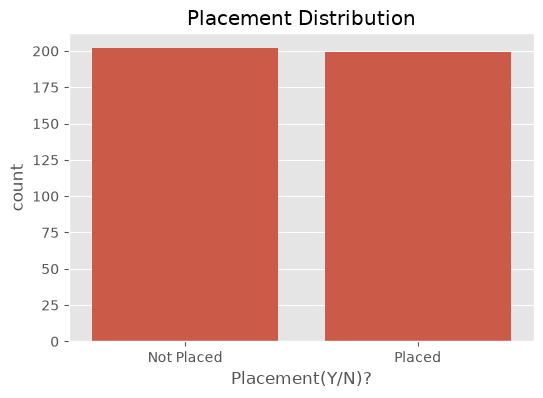

In [18]:
#Placement Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Placement(Y/N)?"
)

plt.title("Placement Distribution")
plt.show()

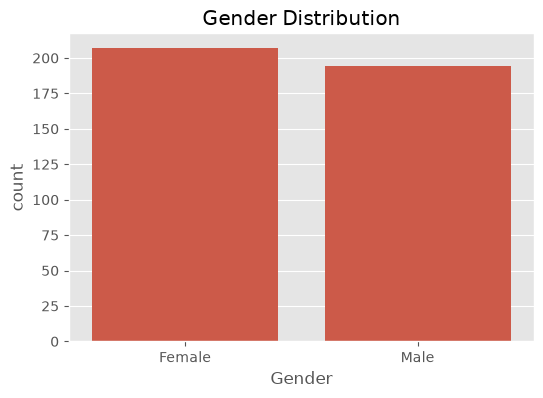

In [19]:
#Gender distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.show()

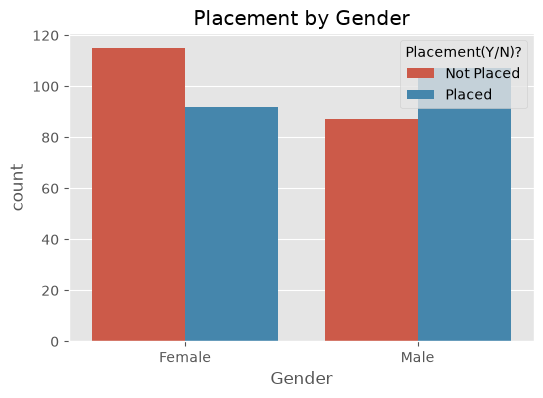

In [20]:
#Placement V/S Gender
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Placement(Y/N)?"
)

plt.title("Placement by Gender")
plt.show()

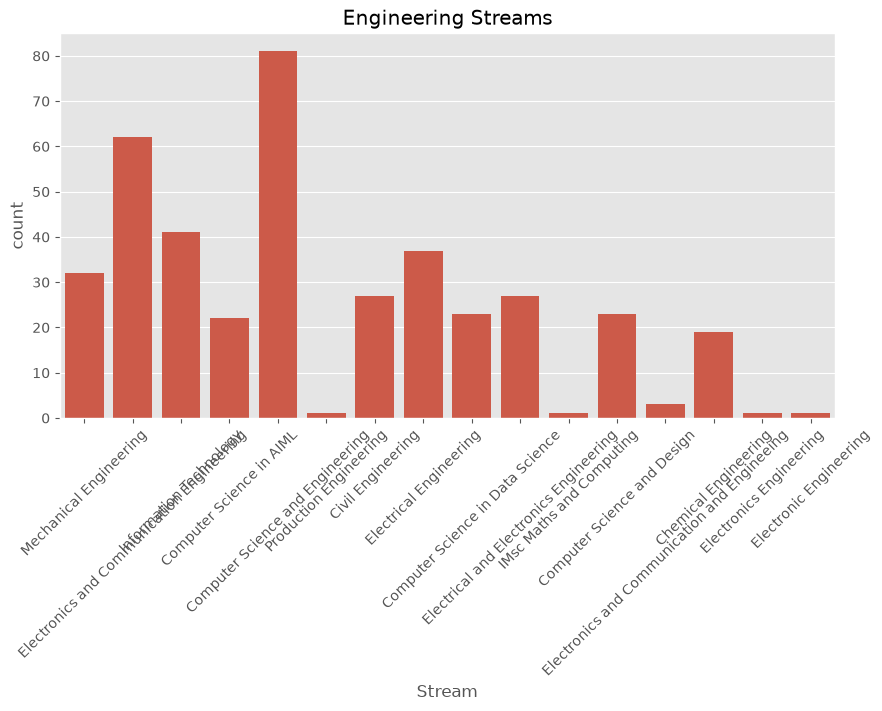

In [21]:
#Stream Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Stream"
)

plt.xticks(rotation=45)

plt.title("Engineering Streams")
plt.show()

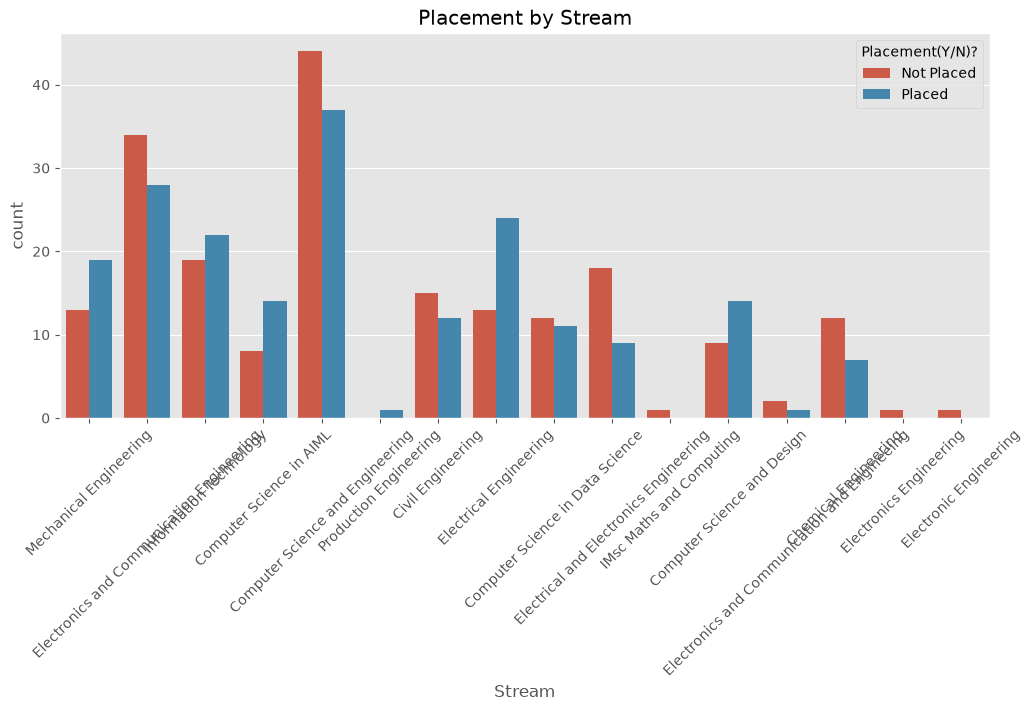

In [22]:
#Placement V/S Stream
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Stream",
    hue="Placement(Y/N)?"
)

plt.xticks(rotation=45)

plt.title("Placement by Stream")
plt.show()

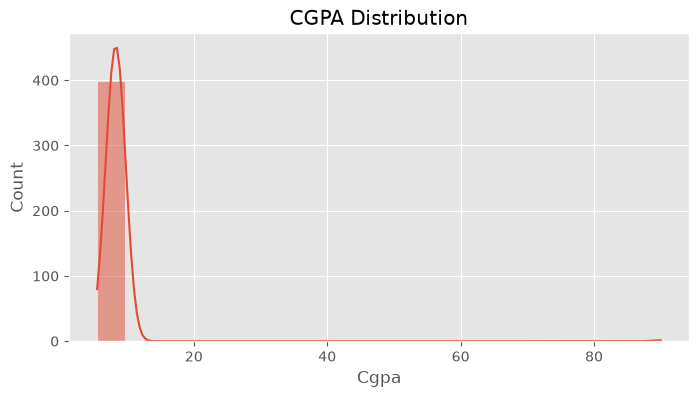

In [23]:
#CGPA Distribution
plt.figure(figsize=(8,4))

sns.histplot(
    df["Cgpa"],
    bins=20,
    kde=True
)

plt.title("CGPA Distribution")
plt.show()

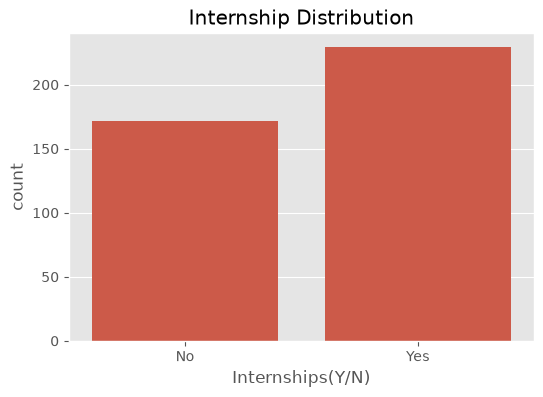

In [24]:
#Internship Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Internships(Y/N)"
)

plt.title("Internship Distribution")
plt.show()

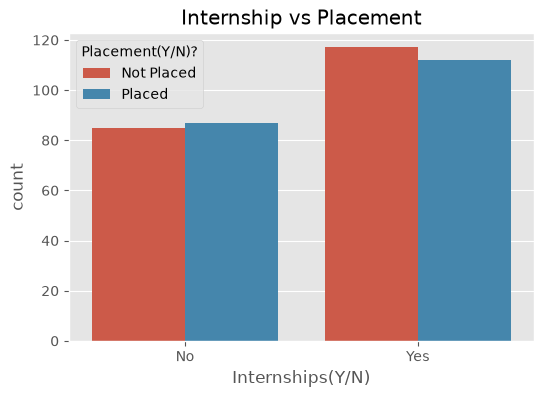

In [25]:
#Internship V/S Placement
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Internships(Y/N)",
    hue="Placement(Y/N)?"
)

plt.title("Internship vs Placement")
plt.show()

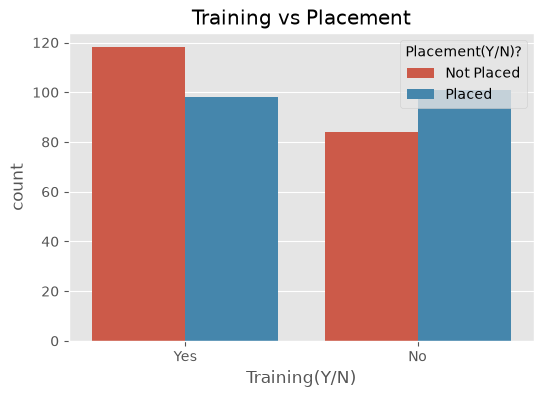

In [26]:
#Training V/S Placement
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Training(Y/N)",
    hue="Placement(Y/N)?"
)

plt.title("Training vs Placement")
plt.show()

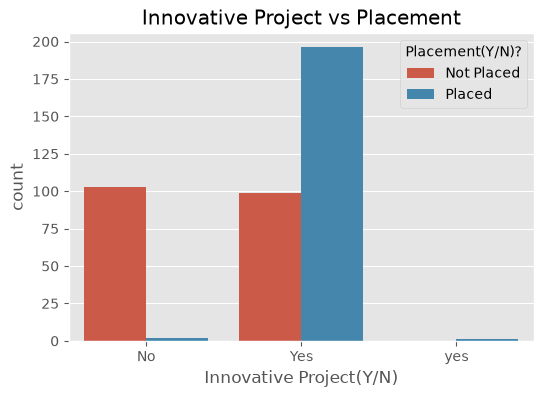

In [27]:
#Innovative Project vs Placement
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Innovative Project(Y/N)",
    hue="Placement(Y/N)?"
)

plt.title("Innovative Project vs Placement")
plt.show()

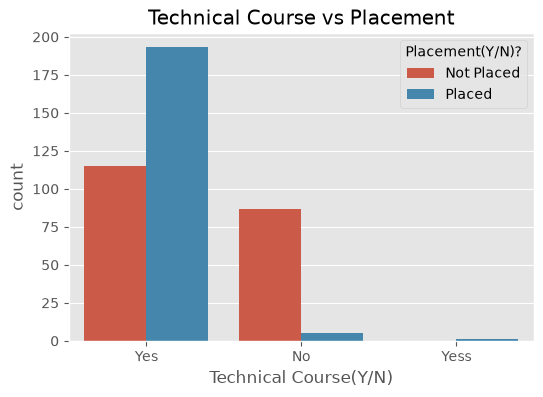

In [28]:
#Technical Course vs Placement
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Technical Course(Y/N)",
    hue="Placement(Y/N)?"
)

plt.title("Technical Course vs Placement")
plt.show()

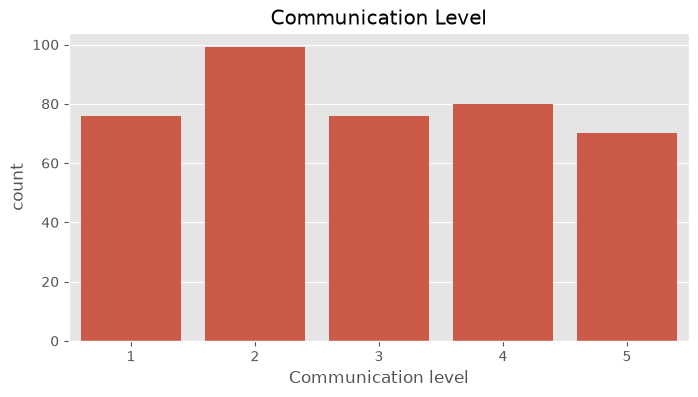

In [29]:
#Communication Level Distribution
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Communication level"
)

plt.title("Communication Level")
plt.show()

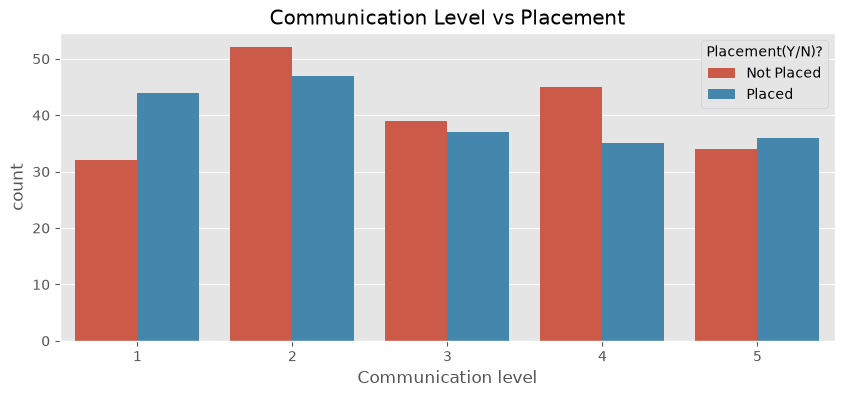

In [30]:
#Communication Level vs Placement
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="Communication level",
    hue="Placement(Y/N)?"
)

plt.title("Communication Level vs Placement")
plt.show()

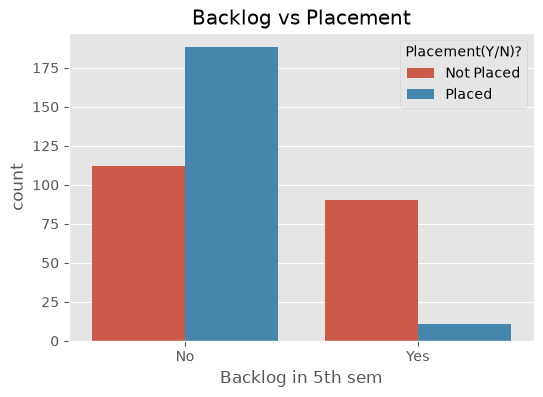

In [31]:
#Backlog vs Placement
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Backlog in 5th sem",
    hue="Placement(Y/N)?"
)

plt.title("Backlog vs Placement")
plt.show()

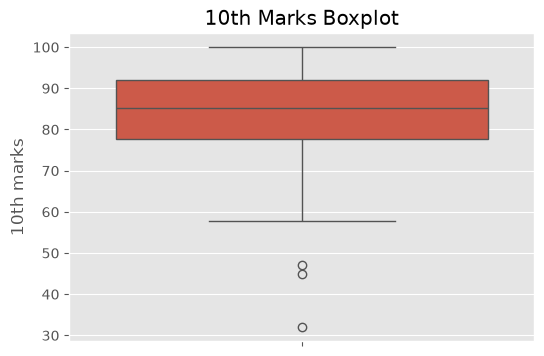

In [32]:
#Boxplot of 10th Marks
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["10th marks"]
)

plt.title("10th Marks Boxplot")
plt.show()

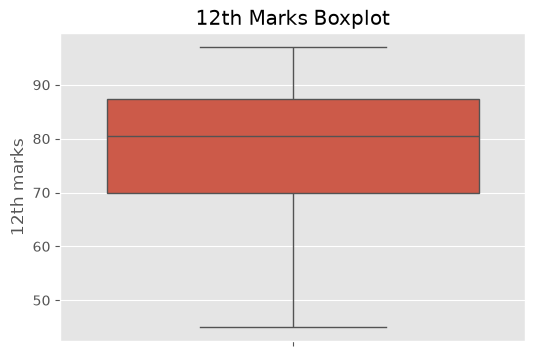

In [33]:
#Boxplot of 12th Marks
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["12th marks"]
)

plt.title("12th Marks Boxplot")
plt.show()

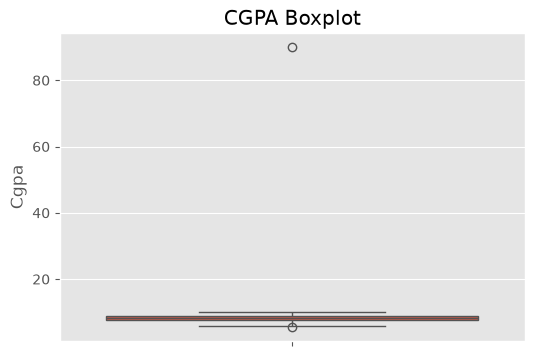

In [34]:
#Boxplot of CGPA
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Cgpa"]
)

plt.title("CGPA Boxplot")
plt.show()

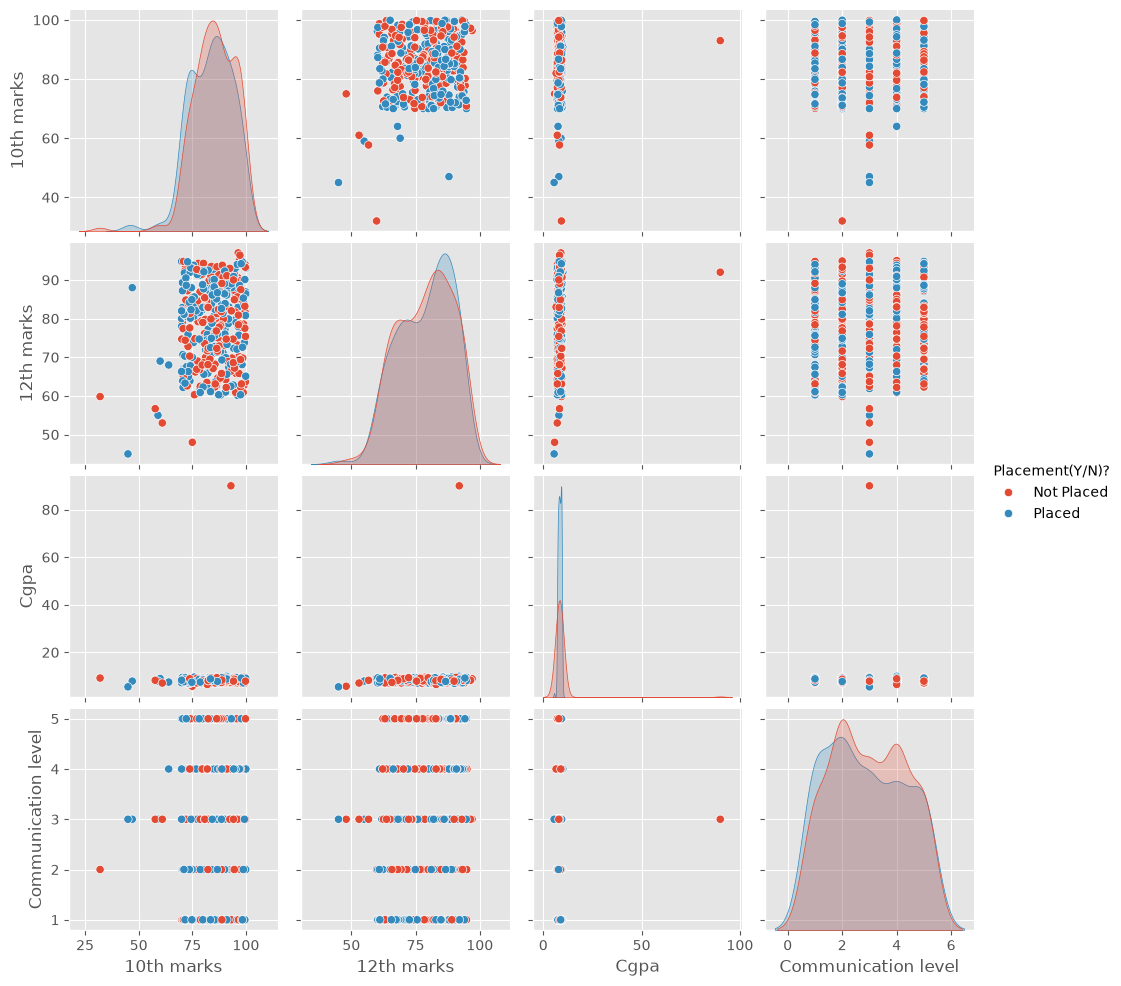

In [35]:
sns.pairplot(
    df[["10th marks","12th marks","Cgpa","Communication level","Placement(Y/N)?"]],
    hue="Placement(Y/N)?"
)

plt.show()
